In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [ ]:
import equinox as eqx
import esm  # pip install fair-esm==2.0.0
import esm2quinox
import jax.random as jrandom
import optax  # pip install optax
from dataset.dataset import initialize_datasets, Dataset_PEPBI
from functions.model import AFF_PREDICTOR,stripped_PREDICTOR
from functions.training import train_model, eval_step, train_model_validation
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import jax.random as jr
import jax
import pandas as pd
from torch.utils.data import DataLoader, RandomSampler, random_split
import jax.tree_util as jtu

In [9]:
base_path = '/home/kunzj'
#base_path = '"/home/jkunz/master_uni_hd/internship_amsterdam'

pepbi dataset

In [ ]:
# data_train = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/pepbi/min_max_scaled/train_data_pepbi.csv",
#     transform=esm2quinox.tokenise
# )
# train_loader = DataLoader(data_train,batch_size=20)
# sns.kdeplot(data_train.aff_Vals)

# data_test = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/pepbi/min_max_scaled/test_data_pepbi.csv",
#     transform=esm2quinox.tokenise
# )
# test_loader = DataLoader(data_test,batch_size=1)
# test_key_init = jrandom.PRNGKey(1)

mmpbsa dataset

In [53]:
data = Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/finished_data_cosine_sim.csv",
    transform=esm2quinox.tokenise
)
size_data = data.__len__()

mmpbsa_data_loader = DataLoader(data,batch_size=1)
# train_loader = DataLoader(data,batch_size=3)
# # split dataset into training and test set

# train_size = int(size_data * 0.9)
# test_size = size_data - train_size
# training_data, test_data = random_split(data, [train_size, test_size])
# #sampler = RandomSampler(training_data, replacement=True, num_samples=500)
# train_loader = DataLoader(training_data, batch_size=8)
# test_loader = DataLoader(test_data, batch_size=1)



weird dataset

In [ ]:
# data_train = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/train.csv",
#     transform=esm2quinox.tokenise,
# )
# train_loader = DataLoader(data_train, batch_size=20)


# data_validation = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/validation.csv",
#     transform=esm2quinox.tokenise,
# )
# validation_loader = DataLoader(data_validation, batch_size=1)

# data_test = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/test.csv",
#     transform=esm2quinox.tokenise,
# )
# test_loader = DataLoader(data_test, batch_size=1)

# test_key_init = jrandom.PRNGKey(1)

weird dataset - cosine similarity


In [23]:
data_train = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/cosine_sim_scaled/train.csv",
    transform=esm2quinox.tokenise,
)
train_loader = DataLoader(data_train, batch_size=30)


data_validation = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/cosine_sim_scaled/validation.csv",
    transform=esm2quinox.tokenise,
)
validation_loader = DataLoader(data_validation, batch_size=1)

data_test = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/cosine_sim_scaled/test.csv",
    transform=esm2quinox.tokenise,
)
test_loader = DataLoader(data_test, batch_size=1)

test_key_init = jrandom.PRNGKey(1)

model initilialization

In [24]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t6_8M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(stripped_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))


In [ ]:
# eqx.tree_serialise_leaves('/home/jkunz/master_uni_hd/internship_amsterdam/carbon/BindCraft_uva_internship/notebooks/test.txt',model_aff)

In [ ]:
target_str =['QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSECLKRIGDELDSNMELQRMIAAVDTDSPREVFFRVAADMFSDGNFNWGRVVALFYFASKLVLKALCTKVPELIRTIMGWTLDFLRERLLGWIQDQGGWDGLLSYFG']
x_prot = esm2quinox.tokenise(target_str)

train model

In [ ]:
# train model
best_model, model_state, train_losses = train_model(
    training_DataLoader=train_loader,
    max_epochs=5,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

In [25]:
best_model, model_state, train_losses, val_losses = train_model_validation(
    training_DataLoader=train_loader,
    validation_Dataloader=validation_loader,
    max_epochs=35,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

Epochs:   0%|          | 0/35 [00:00<?, ?it/s]






Epochs:   3%|▎         | 1/35 [00:34<19:38, 34.66s/it]

[Epoch 1] Train Loss: 0.213712, Val Loss: 0.335565
	(New best model saved.)






Epochs:   6%|▌         | 2/35 [00:36<08:31, 15.49s/it]

[Epoch 2] Train Loss: 0.184644, Val Loss: 0.323979
	(New best model saved.)


...

[Epoch 33] Train Loss: 0.093214, Val Loss: 0.279024






Epochs:  97%|█████████▋| 34/35 [01:42<00:02,  2.06s/it]

[Epoch 34] Train Loss: 0.089192, Val Loss: 0.296920






Epochs: 100%|██████████| 35/35 [01:44<00:00,  2.99s/it]

[Epoch 35] Train Loss: 0.083005, Val Loss: 0.290515
Training complete.


test

In [54]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(test_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


[Entry 1] , Test Loss: 3.359, Predicted Y: 0.054, , True Y: -3.305
[Entry 2] , Test Loss: 3.704, Predicted Y: -0.057, , True Y: -3.761
[Entry 3] , Test Loss: 3.847, Predicted Y: -0.020, , True Y: -3.868
[Entry 4] , Test Loss: 4.796, Predicted Y: 0.300, , True Y: -4.496
[Entry 5] , Test Loss: 3.736, Predicted Y: 0.265, , True Y: -3.471
[Entry 6] , Test Loss: 2.912, Predicted Y: 0.352, , True Y: -2.559
[Entry 7] , Test Loss: 2.903, Predicted Y: 0.094, , True Y: -2.809
[Entry 8] , Test Loss: 3.429, Predicted Y: 0.055, , True Y: -3.373
[Entry 9] , Test Loss: 2.832, Predicted Y: 0.144, , True Y: -2.688
[Entry 10] , Test Loss: 2.599, Predicted Y: 0.358, , True Y: -2.241
[Entry 11] , Test Loss: 2.851, Predicted Y: 0.174, , True Y: -2.677


In [55]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(mmpbsa_data_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


[Entry 1] , Test Loss: 0.263, Predicted Y: 0.009, , True Y: 0.272
[Entry 2] , Test Loss: 0.053, Predicted Y: 0.244, , True Y: 0.298
[Entry 3] , Test Loss: 0.107, Predicted Y: 0.268, , True Y: 0.162
[Entry 4] , Test Loss: 0.118, Predicted Y: 0.038, , True Y: -0.080
[Entry 5] , Test Loss: 0.192, Predicted Y: 0.140, , True Y: -0.052
[Entry 6] , Test Loss: 0.362, Predicted Y: 0.049, , True Y: -0.313
[Entry 7] , Test Loss: 0.652, Predicted Y: 0.125, , True Y: -0.527
[Entry 8] , Test Loss: 0.082, Predicted Y: 0.116, , True Y: 0.034
[Entry 9] , Test Loss: 0.847, Predicted Y: -0.050, , True Y: -0.897
[Entry 10] , Test Loss: 0.375, Predicted Y: -0.057, , True Y: -0.432
[Entry 11] , Test Loss: 0.316, Predicted Y: 0.237, , True Y: -0.079
[Entry 12] , Test Loss: 0.081, Predicted Y: 0.144, , True Y: 0.224
[Entry 13] , Test Loss: 0.079, Predicted Y: 0.129, , True Y: 0.050
[Entry 14] , Test Loss: 0.056, Predicted Y: 0.094, , True Y: 0.151
[Entry 15] , Test Loss: 0.222, Predicted Y: 0.010, , True Y: 0

<Axes: >

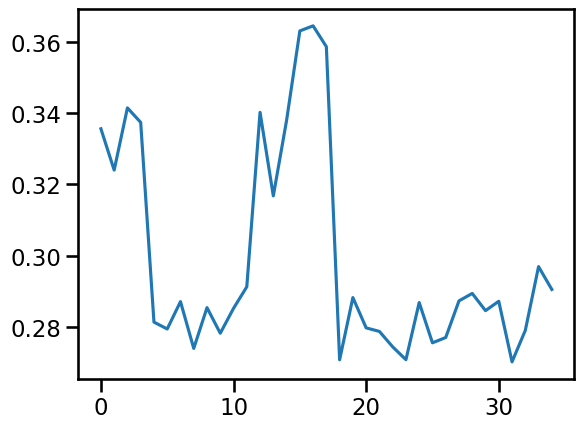

In [48]:
sns.lineplot(val_losses)

<Axes: >

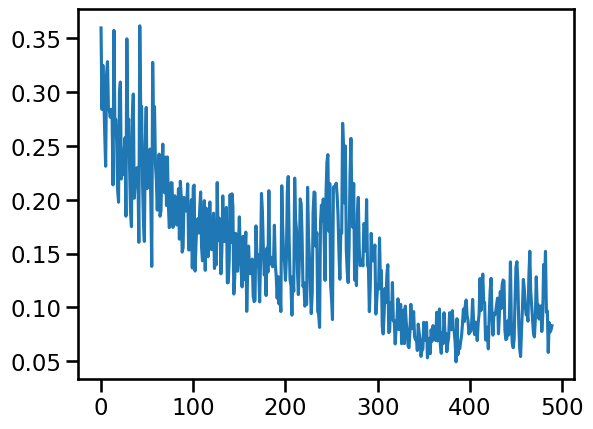

In [49]:
sns.lineplot(train_losses)

In [50]:
from functions import plots

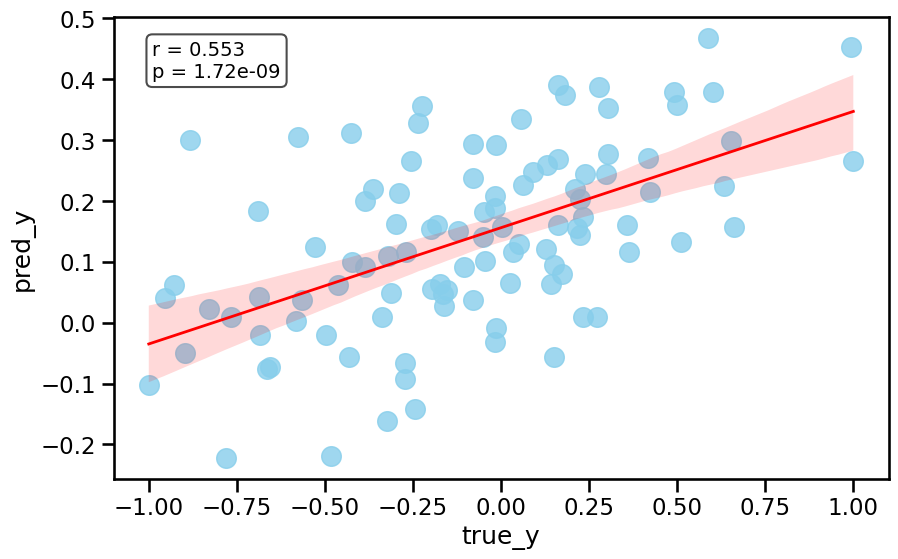

In [56]:
plots.linear_corr_plot(y_val_list,pred_y_list,'true_y','pred_y')

<Axes: >

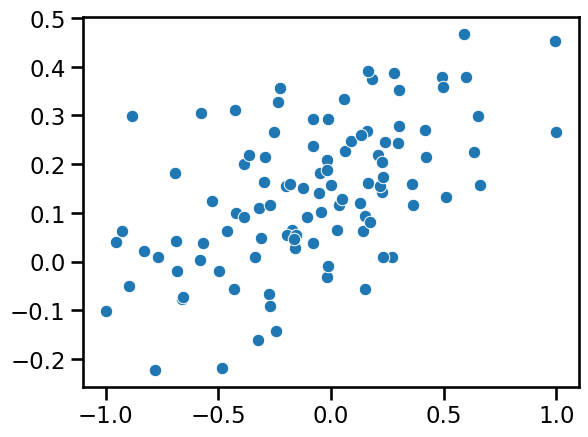

In [57]:
sns.scatterplot(x=y_val_list,y=pred_y_list)

<Axes: >

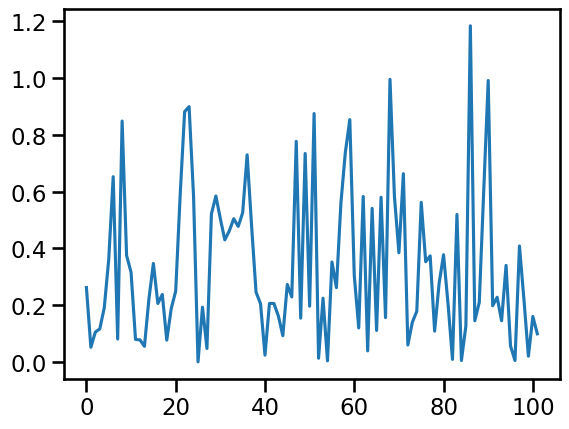

In [58]:
sns.lineplot(test_loss_list)

<Axes: ylabel='Density'>

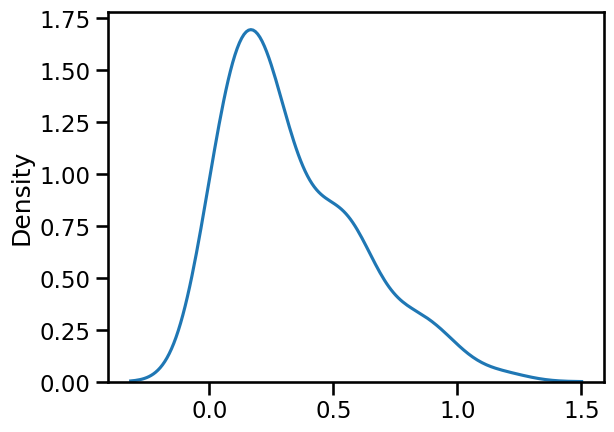

In [59]:
sns.kdeplot(test_loss_list)

In [70]:
eqx.tree_serialise_leaves('../params/model_inference.eqx',inference_model)

In [75]:
test = eqx.tree_deserialise_leaves('../params/model_inference.eqx',inference_model)

In [77]:
assert test == inference_model

In [76]:
test

Partial(
  func=stripped_PREDICTOR(
    esm2=ESM2(
      num_layers=6,
      embed_size=320,
      num_heads=20,
      token_dropout=True,
      layers=TransformerLayer(
        embed_size=320,
        hidden_size=1280,
        num_heads=20,
        attn=MultiheadAttention(
          query_proj=Linear(
            weight=f32[6,320,320],
            bias=f32[6,320],
            in_features=320,
            out_features=320,
            use_bias=True
          ),
          key_proj=Linear(
            weight=f32[6,320,320],
            bias=f32[6,320],
            in_features=320,
            out_features=320,
            use_bias=True
          ),
          value_proj=Linear(
            weight=f32[6,320,320],
            bias=f32[6,320],
            in_features=320,
            out_features=320,
            use_bias=True
          ),
          output_proj=Linear(
            weight=f32[6,320,320],
            bias=f32[6,320],
            in_features=320,
            out_features=320,
 

In [74]:
inference_model

Partial(
  func=stripped_PREDICTOR(
    esm2=ESM2(
      num_layers=6,
      embed_size=320,
      num_heads=20,
      token_dropout=True,
      layers=TransformerLayer(
        embed_size=320,
        hidden_size=1280,
        num_heads=20,
        attn=MultiheadAttention(
          query_proj=Linear(
            weight=f32[6,320,320],
            bias=f32[6,320],
            in_features=320,
            out_features=320,
            use_bias=True
          ),
          key_proj=Linear(
            weight=f32[6,320,320],
            bias=f32[6,320],
            in_features=320,
            out_features=320,
            use_bias=True
          ),
          value_proj=Linear(
            weight=f32[6,320,320],
            bias=f32[6,320],
            in_features=320,
            out_features=320,
            use_bias=True
          ),
          output_proj=Linear(
            weight=f32[6,320,320],
            bias=f32[6,320],
            in_features=320,
            out_features=320,
 

In [79]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model_t, _ = esm.pretrained.esm2_t6_8M_UR50D()
model_esm2_t = esm2quinox.from_torch(torch_model)
model_aff_t, model_state_t = eqx.nn.make_with_state(stripped_PREDICTOR)(
    model=model_esm2_t, key=model_key
)

# set to inference mode
inference_model_t = eqx.nn.inference_mode(model_aff_t)
inference_model_t = eqx.Partial(inference_model_t, state=model_state_t)

# load best inference pretrained model
best_model_aff_t = eqx.tree_deserialise_leaves('/home/kunzj/BindCraft_uva_internship/surr_model/params/model_inference.eqx',inference_model_t)


In [95]:
if jnp.array_equal(best_model_aff_t.func.prot_projection.weight, inference_model.func.prot_projection.weight):
    print('hey')


hey


In [88]:
best_model_aff_t.func.pept_projection.weight

Array([[-0.07229131,  0.04873802, -0.01180777, ..., -0.00420601,
         0.00476772,  0.01637633],
       [-0.03951744, -0.0395222 , -0.02991094, ...,  0.01410224,
        -0.0070739 ,  0.02067995],
       [-0.01972356,  0.02370746, -0.03771086, ..., -0.04037874,
         0.03408757,  0.0060459 ],
       ...,
       [-0.04482295, -0.05278463,  0.05914974, ..., -0.01397477,
         0.08578942,  0.02685089],
       [-0.0009123 , -0.07301988, -0.00823416, ...,  0.05682379,
         0.0307947 , -0.03761819],
       [-0.00284613,  0.01342667, -0.02829379, ...,  0.02989602,
        -0.02554824, -0.00480372]], dtype=float32)